# Mall Customer Segmentation — K-Means Clustering

**AI & Data Science Project**
**Dataset:** Mall Customers Dataset           
**Author:** Noureldeen Bassem

---

## 1. Problem Statement

A mall wants to understand its customers so the marketing team can run targeted campaigns instead of sending the same offer to everyone.

We have membership data for 200 customers: **Gender, Age, Annual Income, and a Spending Score** (1-100, assigned by the mall based on customer behavior and purchase history).

This is an **unsupervised learning** problem — there is no target label telling us the "correct" groups. Our goal is to use **K-Means Clustering** to discover natural customer segments from the data, then profile and name each segment so it becomes something the marketing team can actually act on.

## 2. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

sns.set_style('whitegrid')

We keep the imports minimal — just what we need for data handling, visualization, and the K-Means pipeline itself.

## 3. Loading the Dataset

In [3]:
data = pd.read_csv("Mall_Customers.csv")
df = data.copy()

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset loaded successfully.
Shape: 200 rows x 5 columns


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


We load the CSV and work on a **copy** to keep the original untouched.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Dataset Info & Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


All columns have the correct data types — `Gender` is categorical (`object`), and the rest are numeric. No conversions are needed.

### 4.2 Statistical Summary

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Ages range from 18 to 70, annual income from 15k to 137k, and spending score from 1 to 99. The wide ranges across different scales confirm we'll need to **scale features** before clustering.

### 4.3 Missing Values

In [6]:
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total missing values: 0


There are **no missing values** in the dataset.

### 4.4 Duplicate Rows

In [7]:
print(f"Fully duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate CustomerID entries: {df['CustomerID'].duplicated().sum()}")

Fully duplicate rows: 0
Duplicate CustomerID entries: 0


There are **no duplicate rows**. The dataset is clean, so no cleaning step is required before feature selection.

### 4.5 Feature Distributions

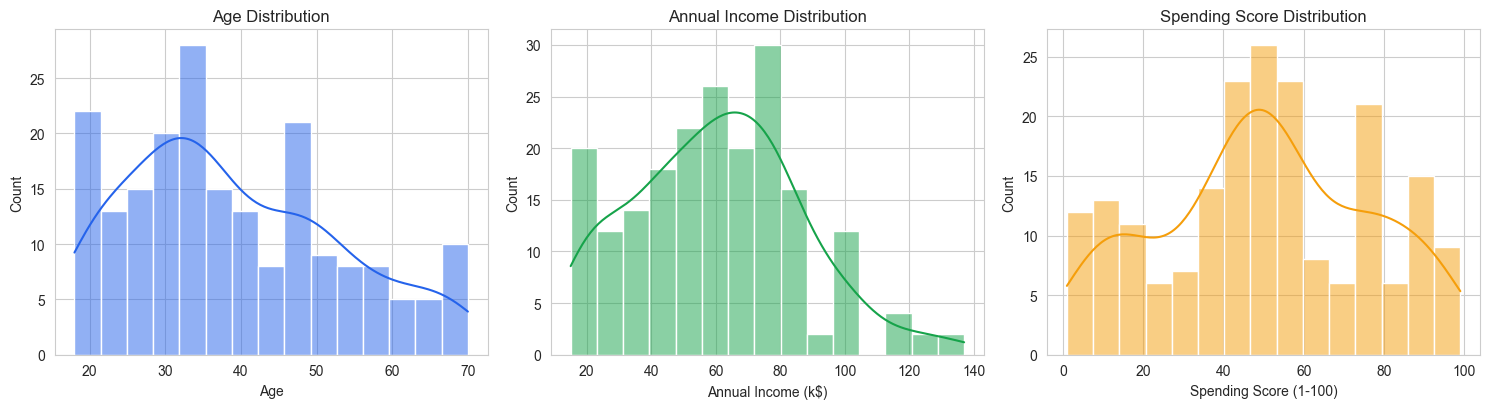

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

sns.histplot(df["Age"], bins=15, kde=True, ax=axes[0], color="#2563eb")
axes[0].set_title("Age Distribution")

sns.histplot(df["Annual Income (k$)"], bins=15, kde=True, ax=axes[1], color="#16a34a")
axes[1].set_title("Annual Income Distribution")

sns.histplot(df["Spending Score (1-100)"], bins=15, kde=True, ax=axes[2], color="#f59e0b")
axes[2].set_title("Spending Score Distribution")

plt.tight_layout()
plt.show()

Age is right-skewed, concentrated among younger customers (mostly 20–40) with a long tail toward older ages. Annual income is approximately normally distributed, centered around 60–80k, with a mild right skew. Spending score is multimodal, with concentrations at the low end, a strong peak in the mid-range (40–60), and a secondary cluster at the high end

### 4.6 Gender Split & Income vs Spending Score

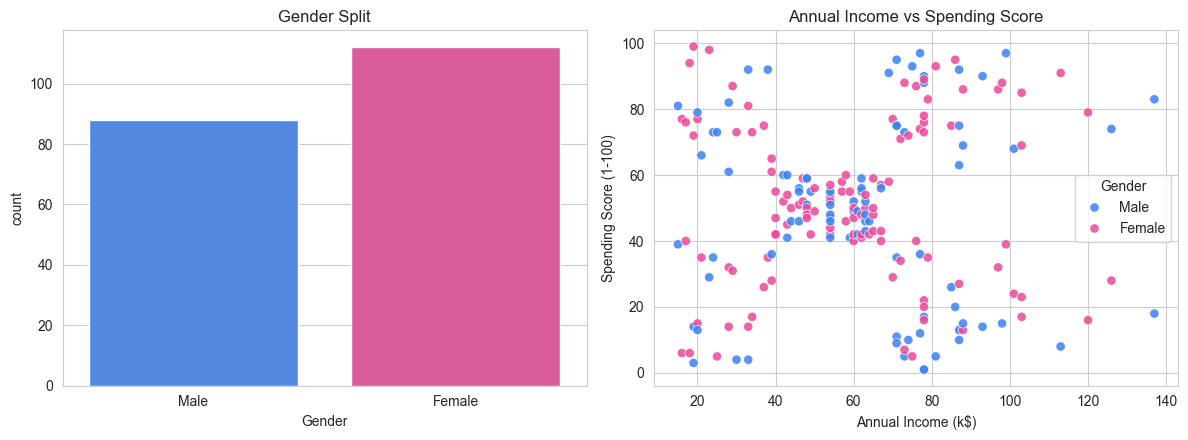

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(data=df, x="Gender", ax=axes[0], palette=["#3b82f6", "#ec4899"])
axes[0].set_title("Gender Split")

sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="Gender",
                 palette=["#3b82f6", "#ec4899"], ax=axes[1], s=45, alpha=0.85)
axes[1].set_title("Annual Income vs Spending Score")

plt.tight_layout()
plt.show()

There are slightly more female customers than male. More importantly, the **Income vs Spending Score** scatter plot already hints at distinct groups of customers — this is the relationship we'll cluster on.

### 4.7 Correlation Analysis

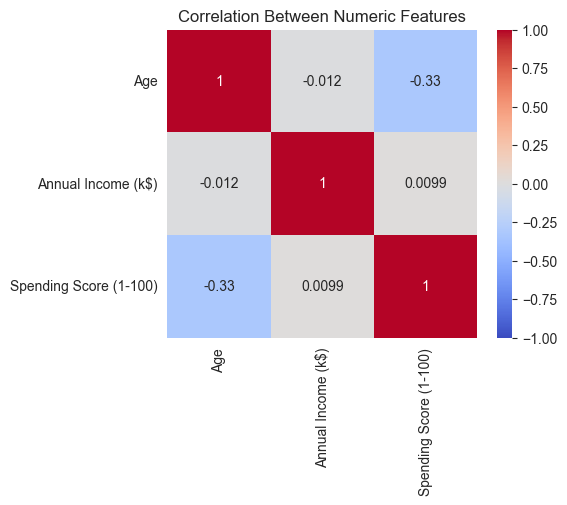

In [10]:
plt.figure(figsize=(5, 4))
sns.heatmap(df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].corr(),
            annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Numeric Features")
plt.show()

Income and Spending Score are essentially uncorrelated, and Age has only a weak negative correlation with Spending Score. This means a simple linear relationship wouldn't explain customer behavior — but **distinct groups** may still exist, which is exactly what clustering is designed to find.

## 5. Data Cleaning

The dataset has no missing values, no duplicates, and correct data types (confirmed during EDA). No cleaning steps are required.

## 6. Feature Selection

We select **Annual Income** and **Spending Score** as the clustering features. This matches the scatter plot above, where the groups are clearly visible, and keeps the clusters easy to visualize in 2D.

`Gender` and `CustomerID` are excluded: `CustomerID` is just a row identifier with no meaning, and `Gender` is categorical with no clear cluster-forming relationship with spending behavior in the scatter plot above.

We keep **Age** aside for cluster *profiling* (Section 10) even though it isn't used to form the clusters themselves — this lets us describe each segment more fully once the clusters are built.

In [12]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].copy()
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## 7. Feature Scaling

K-Means relies on **Euclidean distance**, which is sensitive to scale. Since Income (15-137) and Spending Score (1-99) are on similar ranges here, scaling has a modest effect for this particular pair — but we still apply `StandardScaler` because it's the correct practice for any distance-based algorithm and keeps the pipeline robust if features change later.

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature means (should be ~0):", X_scaled.mean(axis=0).round(3))
print("Scaled feature stds (should be ~1): ", X_scaled.std(axis=0).round(3))

Scaled feature means (should be ~0): [-0. -0.]
Scaled feature stds (should be ~1):  [1. 1.]


## 8. Elbow Method

We train K-Means for a range of `k` values and plot **inertia (WCSS)** against `k`. The optimal `k` is where the curve starts to flatten — adding more clusters beyond that point gives diminishing returns.

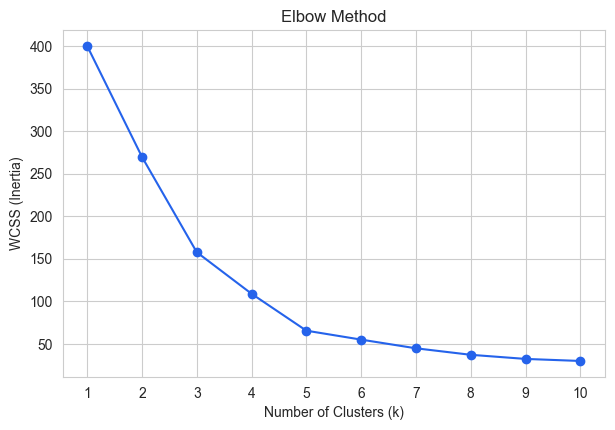

In [14]:
k_range = range(1, 11)
wcss = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 4.5))
plt.plot(list(k_range), wcss, marker="o", color="#2563eb")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(list(k_range))
plt.show()

## 9. Choosing the Optimal Number of Clusters

The curve bends sharply around **k = 5** — WCSS drops steeply up to that point, then flattens out. Adding a 6th or 7th cluster only reduces WCSS marginally, which means k=5 captures the real structure in the data without over-splitting it.

This also matches what we saw visually in the Income vs Spending scatter plot in the EDA — roughly 5 distinct groups of points.

In [15]:
K_FINAL = 5
print(f"Chosen number of clusters: K = {K_FINAL}")

Chosen number of clusters: K = 5


## 10. Training the Final K-Means Model

In [16]:
kmeans = KMeans(n_clusters=K_FINAL, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = cluster_labels
print("Cluster sizes:")
print(df["Cluster"].value_counts().sort_index())

Cluster sizes:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


Every customer now has a `Cluster` number (0-4) assigned based on their scaled Income and Spending Score.

## 11. Cluster Visualization

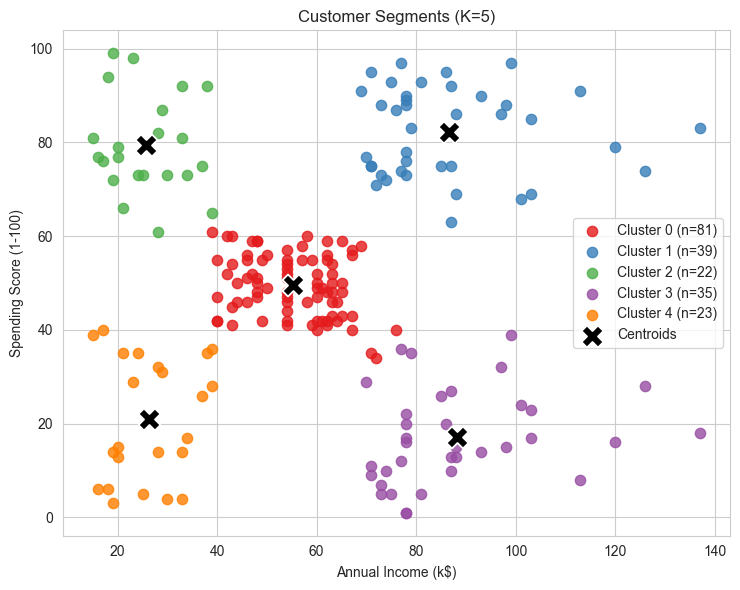

In [17]:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
palette = sns.color_palette("Set1", K_FINAL)

plt.figure(figsize=(7.5, 6))
for c in range(K_FINAL):
    subset = df[df["Cluster"] == c]
    plt.scatter(subset["Annual Income (k$)"], subset["Spending Score (1-100)"],
                s=55, alpha=0.8, color=palette[c], label=f"Cluster {c} (n={len(subset)})")

plt.scatter(centroids_original[:, 0], centroids_original[:, 1], marker="X", s=250,
            c="black", edgecolor="white", linewidth=1.3, label="Centroids", zorder=5)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title(f"Customer Segments (K={K_FINAL})")
plt.legend()
plt.tight_layout()
plt.show()

The five clusters are cleanly separated, with the black X markers showing each cluster's centroid.

## 12. Cluster Profiling

For each cluster, we calculate the **average Age, Annual Income, and Spending Score** to understand who is actually in it.

In [18]:
profile = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
profile["Count"] = df["Cluster"].value_counts().sort_index()
profile

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


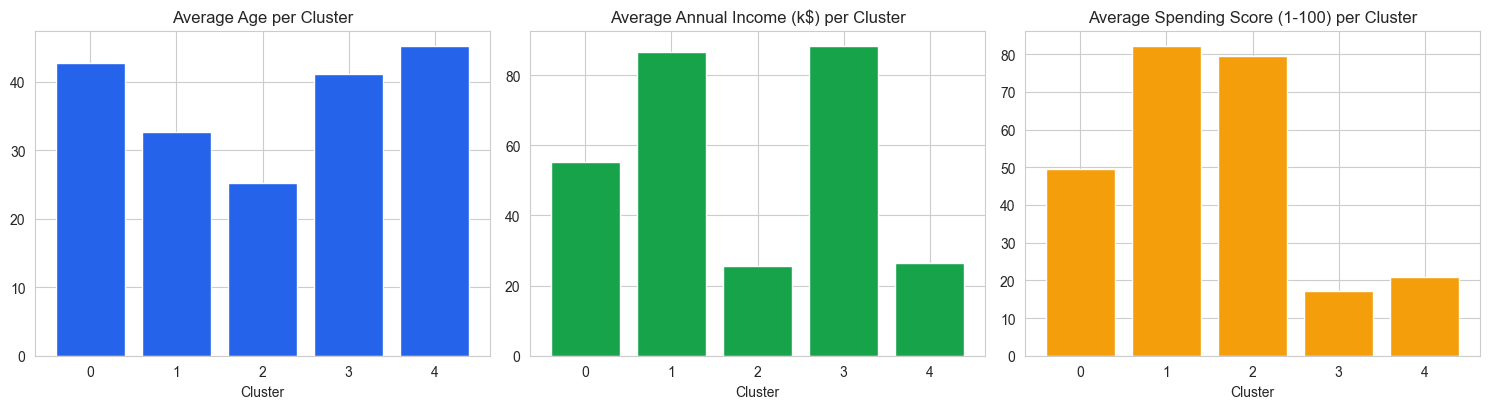

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
colors = ["#2563eb", "#16a34a", "#f59e0b"]

for ax, col, color in zip(axes, cols, colors):
    ax.bar(profile.index.astype(str), profile[col], color=color)
    ax.set_title(f"Average {col} per Cluster")
    ax.set_xlabel("Cluster")

plt.tight_layout()
plt.show()

## 13. Cluster Interpretation & Labeling

We turn the raw numbers into plain-English segment names using each cluster's position relative to the overall median Income and Spending Score:

- **High Income + High Spending** → *High Income, High Spenders*
- **High Income + Low Spending** → *High Income, Cautious Spenders*
- **Low Income + High Spending** → *Low Income, High Spenders*
- **Low Income + Low Spending** → *Budget Conscious Customers*
- **Average Income + Average Spending** → *Average Customers*

In [20]:
income_median = df["Annual Income (k$)"].median()
spend_median = df["Spending Score (1-100)"].median()

def name_segment(row):
    income_band = "High" if row["Annual Income (k$)"] > income_median * 1.1 else \
                  "Low" if row["Annual Income (k$)"] < income_median * 0.9 else "Average"
    spend_band = "High" if row["Spending Score (1-100)"] > spend_median * 1.1 else \
                 "Low" if row["Spending Score (1-100)"] < spend_median * 0.9 else "Average"

    if income_band == "High" and spend_band == "High":
        return "High Income, High Spenders"
    if income_band == "High" and spend_band == "Low":
        return "High Income, Cautious Spenders"
    if income_band == "Low" and spend_band == "High":
        return "Low Income, High Spenders"
    if income_band == "Low" and spend_band == "Low":
        return "Budget Conscious Customers"
    return "Average Customers"

profile["Segment_Name"] = profile.apply(name_segment, axis=1)
profile[["Age", "Annual Income (k$)", "Spending Score (1-100)", "Count", "Segment_Name"]]

,Age,Annual Income (k$),Spending Score (1-100),Count,Segment_Name
Cluster,,,,,
0,42.7,55.3,49.5,81,Average Customers
1,32.7,86.5,82.1,39,"High Income, High Spenders"
2,25.3,25.7,79.4,22,"Low Income, High Spenders"
3,41.1,88.2,17.1,35,"High Income, Cautious Spenders"
4,45.2,26.3,20.9,23,Budget Conscious Customers


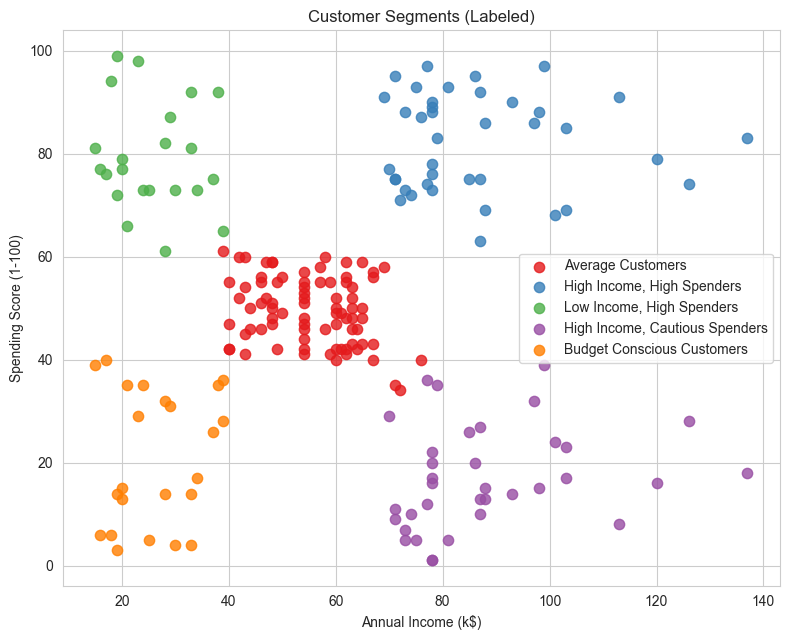

In [21]:
label_map = profile["Segment_Name"].to_dict()
df["Segment"] = df["Cluster"].map(label_map)

plt.figure(figsize=(8, 6.5))
for c in range(K_FINAL):
    subset = df[df["Cluster"] == c]
    plt.scatter(subset["Annual Income (k$)"], subset["Spending Score (1-100)"],
                s=55, alpha=0.8, color=palette[c], label=label_map[c])

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments (Labeled)")
plt.legend()
plt.tight_layout()
plt.show()

Each cluster now has a descriptive, business-friendly name instead of just a number, and the plot legend reflects that directly.

## 14. Saving the Model for Deployment

For deployment, we bundle **scaling + clustering** into a single `sklearn.Pipeline`, so the app never needs to remember to scale inputs manually before predicting — it happens automatically inside the pipeline.

In [24]:
clustering_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=K_FINAL, n_init=10, random_state=42)),
])
clustering_pipeline.fit(df[features])

joblib.dump(clustering_pipeline, "clustering_pipeline.pkl")

profile_export = profile[["Age", "Annual Income (k$)", "Spending Score (1-100)", "Count", "Segment_Name"]].copy()
profile_export.index.name = "Cluster"
profile_export = profile_export.reset_index()

with open("cluster_profiles.json", "w") as f:
    json.dump(profile_export.to_dict(orient="records"), f, indent=2)

print("Saved: models/clustering_pipeline.pkl")
print("Saved: models/cluster_profiles.json")

Saved: models/clustering_pipeline.pkl
Saved: models/cluster_profiles.json


In [21]:
# Quick smoke test: reload the pipeline and predict on a couple of made-up customers
loaded_pipeline = joblib.load("models/clustering_pipeline.pkl")

sample_customers = pd.DataFrame({
    "Annual Income (k$)": [20, 90, 55],
    "Spending Score (1-100)": [15, 88, 50],
})
preds = loaded_pipeline.predict(sample_customers)

with open("models/cluster_profiles.json") as f:
    profiles_lookup = {p["Cluster"]: p["Segment_Name"] for p in json.load(f)}

for (_, row), pred in zip(sample_customers.iterrows(), preds):
    print(f"Income={row['Annual Income (k$)']}k, Spending={row['Spending Score (1-100)']} "
          f"-> Cluster {pred}: {profiles_lookup[pred]}")

Income=20k, Spending=15 -> Cluster 4: Budget Conscious Customers
Income=90k, Spending=88 -> Cluster 1: High Income, High Spenders
Income=55k, Spending=50 -> Cluster 0: Average Customers


We save the entire **pipeline** (scaler + K-Means model) so deployment never needs to retrain or re-fit anything — it just loads the file and calls `.predict()` on raw, unscaled input.

## 15. Conclusion

- The mall customer base splits naturally into **5 segments** based on Annual Income and Spending Score, confirmed by the Elbow Method.
- Each segment was profiled by average Age, Income, and Spending Score, then translated into a business-friendly label instead of a raw cluster number.
- The final deliverable is a single **saved pipeline** (`clustering_pipeline.pkl`) containing scaling + K-Means, plus a **cluster profile lookup** (`cluster_profiles.json`) used to describe predictions in plain language.
- This pipeline is deployed as an interactive **Streamlit app** (`app.py`), where a marketing team member can enter a new customer's Income and Spending Score and instantly see which segment they belong to.